#Analisando as Notas em geral

In [1]:
#Importa a biblioteca Pandas
import pandas as pd

#Solicita a biblioteca que leia o arquivo
notas = pd.read_csv("ratings.csv")

#Solicitar as cinco primeiras linhas do arquivo
notas.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [2]:
#Verifica formato do arquivo
notas.shape

(100836, 4)

In [3]:
#Modifica o nome das colunas para português
notas.columns =  ["usuarioId", "filmeId", "nota", "momento"]
notas.head()

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
#Verificar todos os valores na coluna 'nota'
notas['nota']

,nota
0,4.0
1,4.0
2,4.0
3,5.0
4,5.0
...,...
100831,4.0
100832,5.0
100833,5.0
100834,5.0


In [5]:
#Apresenta os valores que aparecem na série de dados
notas['nota'].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [6]:
#Apresentar a quantidade de vezes que cada valor aparece
notas['nota'].value_counts()

,count
nota,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


In [7]:
#Calcula a média e mediana dos valores das notas
print("Média:", notas['nota'].mean())
print("Mediana:", notas['nota'].median())

Média: 3.501556983616962
Mediana: 3.5


Visualizando Dados Com Histograma e Boxplot

In [8]:
notas.nota.head()

,nota
0,4.0
1,4.0
2,4.0
3,5.0
4,5.0


<Axes: >

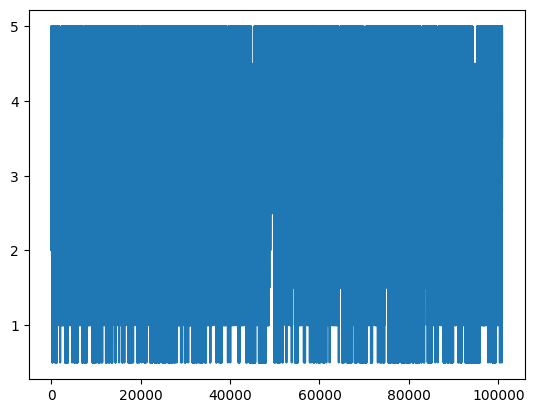

In [9]:
#Plotar os dados
notas.nota.plot()

<Axes: ylabel='Frequency'>

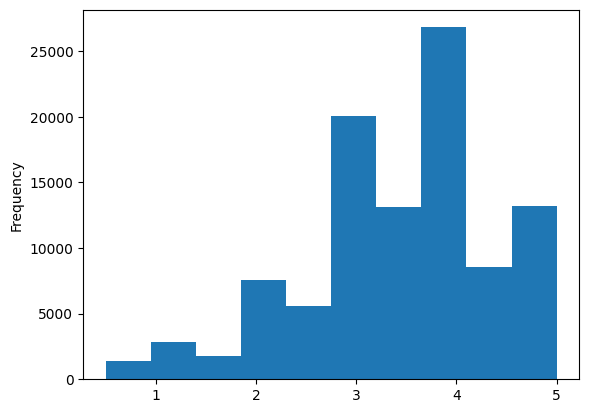

In [10]:
#Plotar os dados na forma de histograma
notas.nota.plot(kind='hist')

In [11]:
#Apresenta várias medidas de descrição
notas.nota.describe()

,nota
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


<Axes: ylabel='nota'>

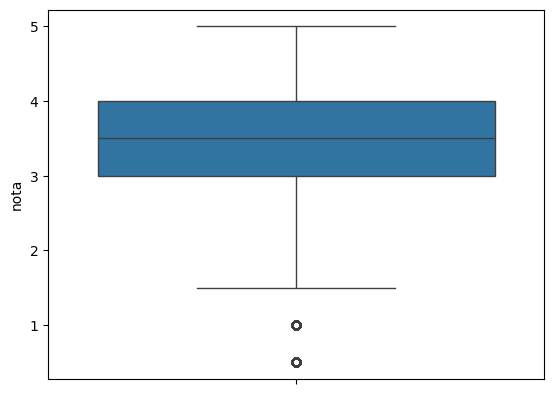

In [12]:
#Importa a biblioteca seborn
import seaborn as sns

#Mostra informações básicas de Maneira visual
sns.boxplot(notas.nota)


#Olhando os Filmes

In [13]:
#Pedir ao pandas para realizar a leitura do arquivo CSV.
filmes = pd.read_csv("movies.csv")

#Altera a descrição das colunas para português
filmes.columns = ["filmeId", "titulo", "generos"]

#Mostrar as cinco primeiras linhas do arquivo
filmes.head()

,filmeId,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [14]:
#Consulta as notas correspondentes a filmeId = 1
notas.query("filmeId==1")

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
516,5,1,4.0,847434962
874,7,1,4.5,1106635946
1434,15,1,2.5,1510577970
1667,17,1,4.5,1305696483
...,...,...,...,...
97364,606,1,2.5,1349082950
98479,607,1,4.0,964744033
98666,608,1,2.5,1117408267
99497,609,1,3.0,847221025


#Analisando Algumas notas específicas por Filmes

In [15]:
#Deixar visível a consluta apenas com a coluna nota e calcular a média
notas.query("filmeId==1").nota.mean()

np.float64(3.9209302325581397)

In [16]:
#Realiza o Agrupamento dos dados por um identificador selecionado, mostrando
#apenas a coluna escolhida
notas.groupby("filmeId").mean()["nota"]

,nota
filmeId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429
...,...
193581,4.000000
193583,3.500000
193585,3.500000


<Axes: ylabel='Frequency'>

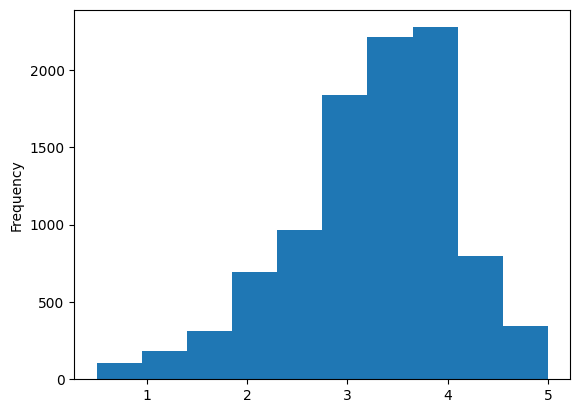

In [17]:
#Cria a varíavel médias por filme e atrivui a ela o cálculo das médias agrupadas
medias_por_filme = notas.groupby("filmeId").mean()["nota"]

#Plotar a medias_por_filme utilizando o histograma
medias_por_filme.plot(kind='hist')

<Axes: ylabel='nota'>

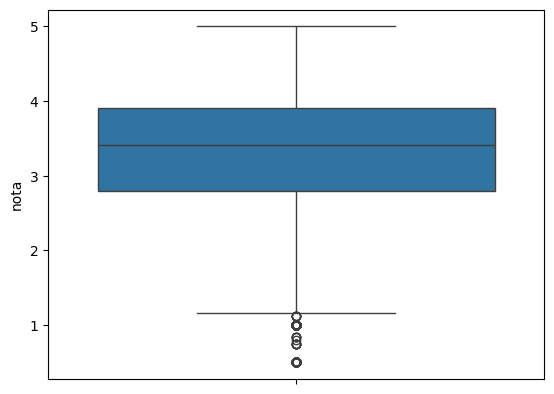

In [18]:
#Apresenta graficamente as  principais informações da variável
sns.boxplot(medias_por_filme)

In [19]:
#Apresenta de Forma numérica as principais informações descritivas sobre a variável medias_por_filme
medias_por_filme.describe()

,nota
count,9724.000000
mean,3.262448
std,0.869874
min,0.500000
25%,2.800000
50%,3.416667
75%,3.911765
max,5.000000


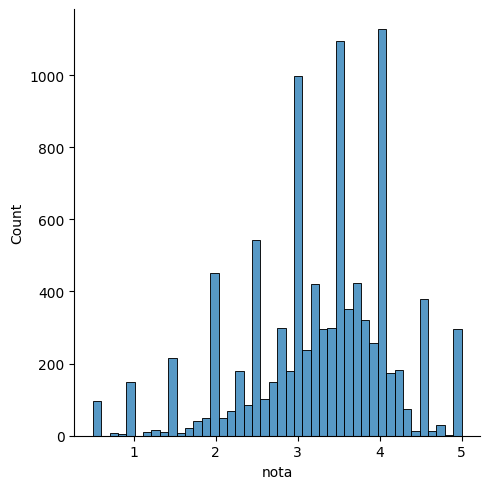

In [20]:
#Mostrar a distribuição dos valores da variável usando o Seaborn
sns.displot(medias_por_filme)

Text(0, 0.5, 'Frequência')

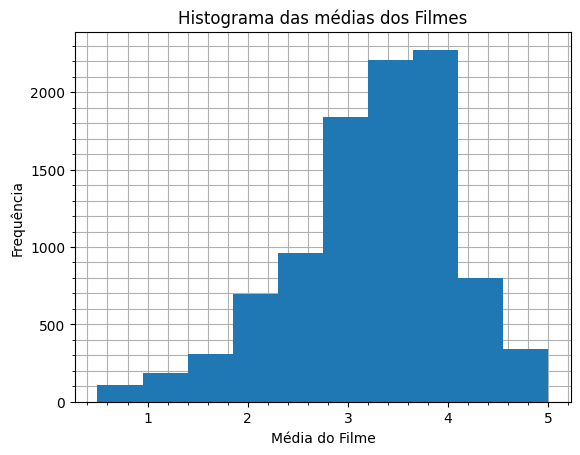

In [21]:
#Importa a biblioteca matplotlib
import matplotlib.pyplot as plt
#Ativar a grade de Linhas
plt.grid(True)
#Mostra a grade de linhas com maior detalhes
plt.minorticks_on()
plt.grid(which='minor')
#Colocar as linhas de grade por trás do gráfico
plt.gca().set_axisbelow(True)
#Plotar o histograma das médias dos filmes
plt.hist(medias_por_filme)
#Exibe o título do Histograma e rótulo dos Eixos
plt.title("Histograma das médias dos Filmes")
plt.xlabel("Média do Filme")
plt.ylabel("Frequência")

In [22]:
#Carrega o Arquivo e Mostra os cinco primeiros valores
tmdb = pd.read_csv("tmdb_5000_movies.csv")
tmdb.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2.787965e+09,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800.0
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,9.610000e+08,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500.0
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,8.806746e+08,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466.0
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1.084939e+09,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106.0
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,2.841391e+08,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124.0


In [23]:
#Mostra os Valores que aparecem em uma das variáveis escolhidas
tmdb.original_language.unique()

array(['en', 'ja', 'fr', 'zh', 'es', 'de', 'hi', 'ru', 'ko', 'te', 'cn',
       'it', 'nl', 'ta'], dtype=object)

In [24]:
#Lista os Valores de uma coluna específica
tmdb["original_language"]

,original_language
0,en
1,en
2,en
3,en
4,en
...,...
2430,en
2431,en
2432,en
2433,en


In [25]:
#Conta os valores em que cada elemento aparece em uma série
tmdb.original_language.value_counts()

,count
original_language,
en,2367
fr,19
zh,13
ja,7
cn,6
ru,6
de,5
es,5
ko,2


In [26]:
#Transforma em uma tabela com duas colunas (to_Frame)
#em que a lingua passa a ser o índice. Depois, cria
#um contador para índice e  deixa a lingua com uma coluna
# e total como outra (reset_index)
contagem_de_lingua = tmdb.original_language.value_counts().to_frame().reset_index()
#Renomeia o cabeçalho das colunas
contagem_de_lingua.columns = ["original_language", "total"]
contagem_de_lingua.head()

,original_language,total
0,en,2367
1,fr,19
2,zh,13
3,ja,7
4,cn,6


<Axes: xlabel='original_language', ylabel='total'>

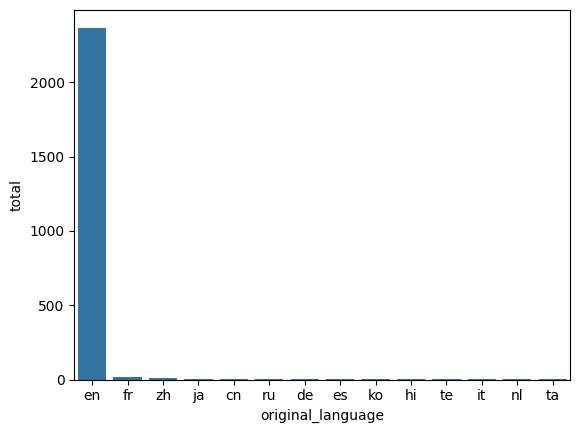

In [27]:
#Mostra um gráfico de categorias
sns.barplot(x = "original_language", y = "total", data=contagem_de_lingua)

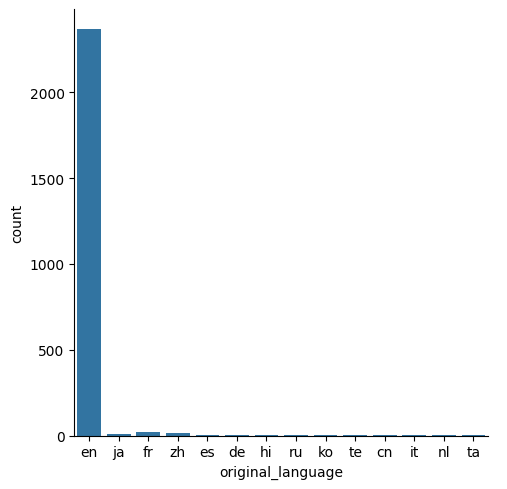

In [28]:
#Mostra um gráfico por categoria extraindo os dados diretamente da tabela
sns.catplot(x = "original_language", kind = "count", data=tmdb)

([<matplotlib.patches.Wedge at 0x7a3b8bd48080>,
 [Text(-1.0957693955332757, 0.09638169853576782, 'en'),
  Text(1.0874914107190383, -0.16541593518254602, 'fr'),
  Text(1.0933920733413196, -0.12039009076485611, 'zh'),
  Text(1.0961342391184432, -0.092139729933573, 'ja'),
  Text(1.0975253864855505, -0.07374297268040643, 'cn'),
  Text(1.098535495099897, -0.05674298199447004, 'ru'),
  Text(1.0992301410277894, -0.041147260613877856, 'de'),
  Text(1.0996695138676216, -0.026962200766057716, 'es'),
  Text(1.0998681675832247, -0.01702979556893294, 'ko'),
  Text(1.099925842653202, -0.01277265296028518, 'hi'),
  Text(1.099955136937924, -0.009934622482684253, 'te'),
  Text(1.0999771119276665, -0.007096001357836736, 'it'),
  Text(1.0999917593553021, -0.004257857492601435, 'nl'),
  Text(1.0999990845372254, -0.0014191607612976922, 'ta')])

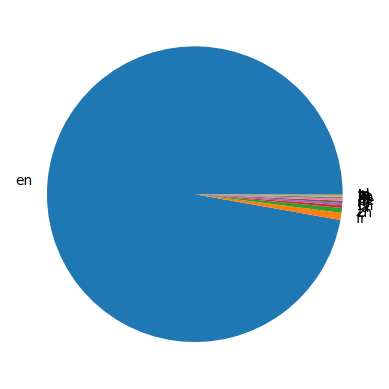

In [29]:
#Mostra um gráfico de pizza utilizando o Matplotlib
plt.pie(contagem_de_lingua["total"], labels = contagem_de_lingua ["original_language"])

In [30]:
#Realizar o processo de separação dos dados
#Iniciar com a contagem dos dados
total_por_língua = tmdb["original_language"].value_counts()
#Mostra o total de todos os parâmetros
total_geral  = total_por_língua.sum()
#Mostra o total de  um parâmetro específico
total_de_ingles = total_por_língua.loc["en"]
#Mostra a diferença entre o total geral e o total do parâmetro escolhido
total_do_resto = total_geral - total_de_ingles
print("Inglês:", total_de_ingles, "Outras Línguas:", total_do_resto)

Inglês: 2367 Outras Línguas: 68


In [31]:
#Agrupa os dados para criar um dataframe
dados = {
    'lingua': ["Inglês", "Outras Línguas"],
    'total': [total_de_ingles, total_do_resto]
}
dados

{'lingua': ['Inglês', 'Outras Línguas'],
 'total': [np.int64(2367), np.int64(68)]}

In [32]:
#Mostra o data frame com os dados
pd.DataFrame(dados)

,lingua,total
0,Inglês,2367
1,Outras Línguas,68


<Axes: xlabel='lingua', ylabel='total'>

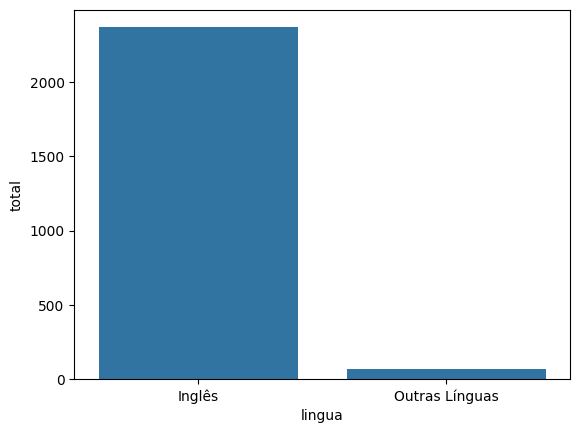

In [33]:
#Mostra o gráfico com os dados
sns.barplot(x="lingua", y="total", data=pd.DataFrame(dados))

([<matplotlib.patches.Wedge at 0x7a3b8b760080>,
 [Text(-1.0957693955332757, 0.09638169853576782, 'Inglês'),
  Text(1.0957694039592276, -0.09638160274056067, 'Outras Línguas')])

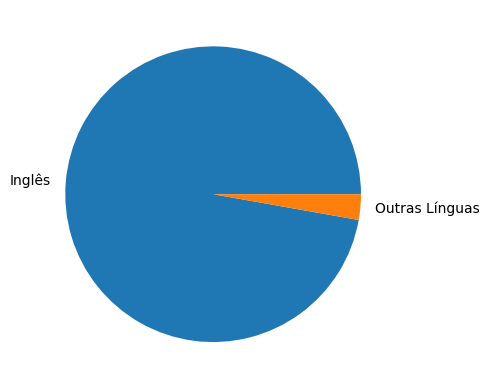

In [34]:
#Mostra um gráfico de Pizza
plt.pie([total_de_ingles, total_do_resto], labels = ["Inglês", "Outras Línguas"])

In [35]:
#Fazendo filtros com conssultas
total_por_lingua_de_outros_filmes = tmdb.query("original_language != 'en'").original_language.value_counts()
total_por_lingua_de_outros_filmes

,count
original_language,
fr,19
zh,13
ja,7
cn,6
ru,6
de,5
es,5
ko,2
hi,1


/tmp/ipython-input-2737044116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = "original_language", kind = "count",


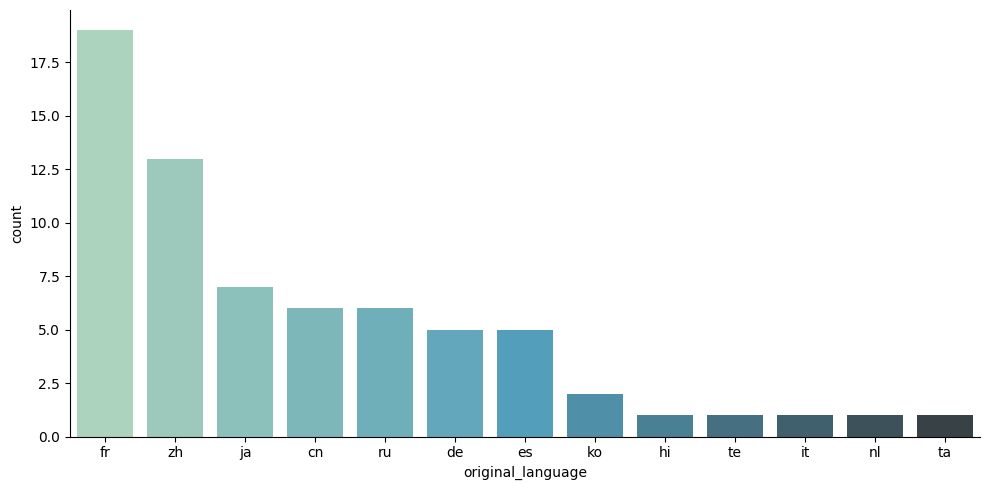

In [41]:
#Realiza a consulta isolando os filmes com lingua original diferente de inglês
filmes_sem_lingua_original_em_ingles = tmdb.query("original_language != 'en'")

#Plota um gráfico de categorias com a consulta realizada, utilizando o atributo
#'aspect' para configurar o tamanho do gráfico
#'order' para determinar a organização  dos parâmetros em ordem decrescente
#'palette' determina a paleta de cores do gráfico
sns.catplot(x = "original_language", kind = "count",
            data=filmes_sem_lingua_original_em_ingles,
            aspect = 2,
            palette = "GnBu_d",
            order = total_por_lingua_de_outros_filmes.index)

In [42]:
#Exibir as duas primeiras linhas do arquivo movies.csv
filmes.head(2)

,filmeId,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy


In [43]:
#Buscar as notas e imprimir as notas na tela
notas_do_toy_story = notas.query("filmeId==1")
notas_do_jumanji = notas.query("filmeId==2")
print(len(notas_do_toy_story), len(notas_do_jumanji))

215 110


In [44]:
#Imprimir as médias das notas dos filmes
print("Nota média do Toy Story %.2f" % notas_do_toy_story.nota.mean())
print("Nota média do Jumanji %.2f" % notas_do_jumanji.nota.mean())

Nota média do Toy Story 3.92
Nota média do Jumanji 3.43


In [45]:
#Imprimindo a mediana das notas
print("Mediana do Toy Story %.2f" % notas_do_toy_story.nota.median())
print("Mediana do Jumanji %.2f" % notas_do_jumanji.nota.median())

Mediana do Toy Story 4.00
Mediana do Jumanji 3.50


In [46]:
#Importa o numpy, cria um array e calcula a média
import numpy as np

np.array([2.5] * 10).mean()

np.float64(2.5)

In [47]:
#Criando novo array
np.array([3.5] *10)
#Utiliza a função append() para juntar dois arrays e atribui à variável filme1
filme1 = np.append(np.array([2.5] * 10), np.array([3.5] * 10))
#Criar arrays com notas 5 e 1
np.array([5] *10)
np.array([1] *10)
#Criar variável filme2 e atribui o conjunto dos dois arrays com a função append()
filme2 = np.append(np.array([5] * 10), np.array([1] * 10))
#Imprime a media dos filmes
print(filme1.mean(), filme2.mean())

3.0 3.0


In [48]:
#Imprime a mediana dos dois filmes
print(np.median(filme1), np.median(filme2))

3.0 3.0


(array([10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

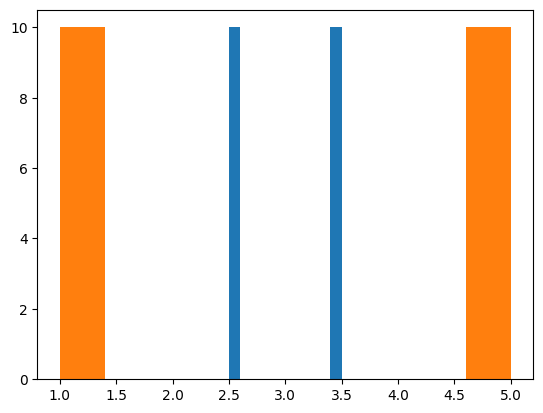

In [49]:
#Plotar os gráficos em histograma, utilizando o Matplotlib
plt.hist(filme1)
plt.hist(filme2)

{'whiskers': [<matplotlib.lines.Line2D at 0x7a3b80c6f0b0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a3b80c6f710>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a3b80c64b00>,
 'medians': [<matplotlib.lines.Line2D at 0x7a3b80c6fb30>,
 'fliers': [<matplotlib.lines.Line2D at 0x7a3b80c6fe90>,
 'means': []}

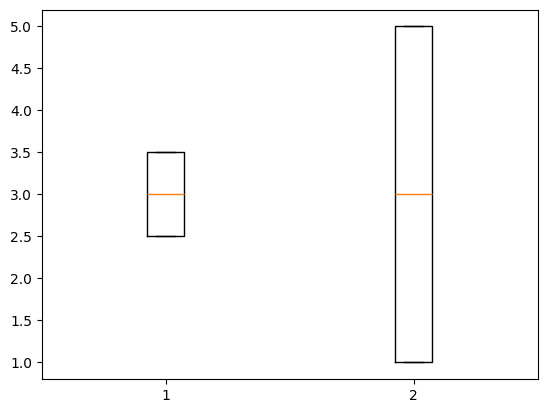

In [50]:
#Plotar o boxplot das notas do filme
plt.boxplot([filme1,filme2])

{'whiskers': [<matplotlib.lines.Line2D at 0x7a3b804b2120>,
 'caps': [<matplotlib.lines.Line2D at 0x7a3b804b2570>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a3b80c65fa0>,
 'medians': [<matplotlib.lines.Line2D at 0x7a3b804b2b70>,
 'fliers': [<matplotlib.lines.Line2D at 0x7a3b804b2ea0>,
 'means': []}

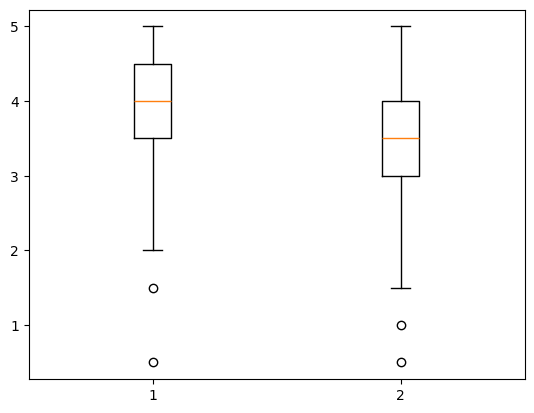

In [51]:
#Fazendo o boxplot das notas
plt.boxplot([notas_do_toy_story.nota, notas_do_jumanji.nota])

<Axes: xlabel='filmeId', ylabel='nota'>

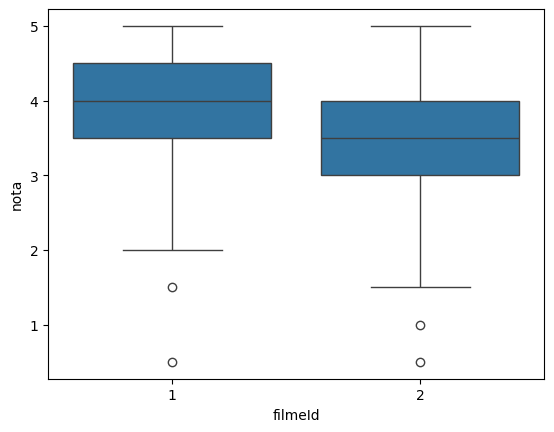

In [52]:
#Fazendo o Boxplot das notas com o Seaborn
sns.boxplot(x = "filmeId", y = "nota", data = notas.query("filmeId in (1,2)"))

<Axes: xlabel='filmeId', ylabel='nota'>

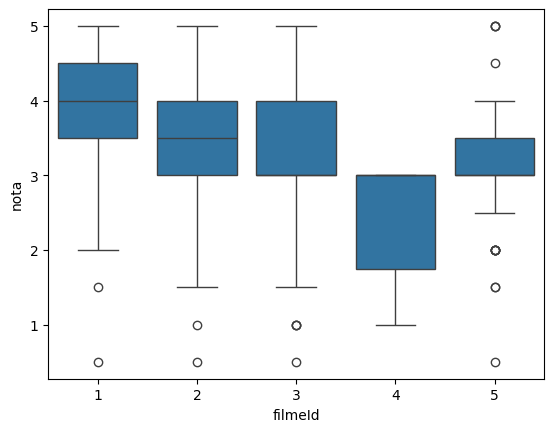

In [53]:
#Plotando os filmes de Id de 1 a 5
sns.boxplot(x = "filmeId", y = "nota", data = notas.query("filmeId in (1,2,3,4,5)"))

In [54]:
#Imprimir o Desvio Padrao dos Filmes Toy Story e Jumanji
print("Desvio padrão do Jumanji %.2f" % notas_do_jumanji.nota.std(), "Desvio padrão do Toy Story %.2f" % notas_do_toy_story.nota.std())

Desvio padrão do Jumanji 0.88 Desvio padrão do Toy Story 0.83


In [55]:
#Imprimindo dados descritivos dos filme1 e filme2
print(np.mean(filme1), np.mean(filme2))
print(np.std(filme1), np.std(filme2))
print(np.median(filme1), np.median(filme2))

3.0 3.0
0.5 2.0
3.0 3.0
